# N07 — Tire Degradation EDA

**Scope:** Exploratory Data Analysis focused on tire degradation patterns, intended to guide the design of `N08_tiredeg_model.ipynb` (TCN-based degradation forecaster).

**What this notebook does NOT repeat from prior EDA:**
- Basic lap time distributions, circuit speed ranges → N02
- Concept drift between 2023/2024, anti-drift features → N05
- Leakage audit for `LapTime_s` / `LapTime_Delta` targets → N05 / N06
- General compound usage (SOFT/MEDIUM/HARD proportions) → N02

**What is new here:**
1. **Absolute compound enrichment** — join with `tire_compounds_by_race.json` to get C1–C6 per lap
2. **Degradation target analysis** — define and validate the TCN target variable
3. **Stint temporal structure** — sequence lengths, autocorrelation, stationarity (TCN input design)
4. **Degradation cliff detection** — when and on which compounds does rapid wear occur?
5. **Circuit × absolute compound interaction** — does C3 at Spa degrade differently than C3 at Monaco?
6. **Leakage audit for the degradation target** — different set of leaky features than N06
7. **Feature manifest export** — safe feature set for N08

**Model approach (N08 preview):**
- Architecture: Temporal Convolutional Network (TCN) via PyTorch + PyTorch Lightning
- Strategy: one global model trained on all compounds, then one fine-tuned model per absolute compound (C1–C5)
- Input: fixed-length stint sequence of observable features (no target leakage)
- Output: predicted `FuelAdjustedDegAbsolute` at future stint laps (multi-step regression)

> **Out of scope — future work:** INTERMEDIATE and WET compounds are excluded from this notebook.
> Their performance is governed by track-drying dynamics rather than rubber wear, making
>  a meaningless target for them. A dedicated classification model
> (e.g. *"in how many laps will the track be ready for slicks?"* or *"WET → INTER transition window"*)
> would be a strong addition to the strategy system in a future iteration, using features such as
> ,  trend,  on inters, and visual/sensor track humidity data.

---
**Outputs:**
- `data/processed/laps_tiredeg.parquet` — enriched dataframe with absolute compound columns
- `data/processed/tiredeg_feature_manifest.json` — safe feature list for N08

## Step 0 — Imports & Paths

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

# ── Paths ────────────────────────────────────────────────────────────────────────
repo_root      = Path.cwd()
while not (repo_root / ".git").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

processed_path = repo_root / "data" / "processed"
compounds_path = repo_root / "data" / "tire_compounds_by_race.json"
outputs_path   = Path.cwd() / "outputs"   # local to this notebook folder
outputs_path.mkdir(parents=True, exist_ok=True)

print(f"Repo root : {repo_root}")
print(f"Outputs   : {outputs_path}")


Repo root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Outputs   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\tire_degradation\outputs


## Step 1 — Data Loading & Absolute Compound Enrichment

We load `laps_featured.parquet` (engineered in N04) and join each lap with its absolute Pirelli compound (C1–C6) using `tire_compounds_by_race.json`.

FastF1 only provides relative labels (SOFT/MEDIUM/HARD). The absolute compound is essential for cross-race degradation modelling: a C3 as SOFT degrades very differently from a C3 as HARD.

In [2]:
# GP name aliases — keep consistent with N04
GP_NAME_ALIASES = {
    "Spain":         "Barcelona",   # 2023 test-download artefact
    "Miami Gardens": "Miami",        # 2025 venue rename
}


def _normalize(s):
    """NFC-normalize a string to fix Unicode mismatches (e.g. e + combining accent vs e-acute)."""
    import unicodedata
    return unicodedata.normalize("NFC", str(s)) if pd.notna(s) else s


def load_enriched_laps(processed_path: Path, compounds_path: Path) -> pd.DataFrame:
    """Load laps_featured, apply GP_Name aliases, and join absolute compound."""
    df = pd.read_parquet(processed_path / "laps_featured.parquet")
    df["GP_Name"] = df["GP_Name"].map(_normalize).replace(GP_NAME_ALIASES)

    # Build a flat lookup DataFrame from the JSON and merge
    with open(compounds_path, encoding="utf-8") as f:
        compound_map = json.load(f)

    rows = [
        {"Year": int(yr), "GP_Name": _normalize(gp), "Compound": role, "AbsoluteCompound": compound}
        for yr, gps in compound_map.items()
        if not yr.startswith("_")          # skip metadata keys
        for gp, roles in gps.items()
        for role, compound in roles.items()
    ]
    lookup_df = pd.DataFrame(rows)

    df = df.merge(lookup_df, on=["Year", "GP_Name", "Compound"], how="left")

    # Numeric ID: C1=1 ... C6=6
    compound_num = {"C1": 1, "C2": 2, "C3": 3, "C4": 4, "C5": 5, "C6": 6}
    df["AbsoluteCompoundID"] = df["AbsoluteCompound"].map(compound_num)

    # Hardness score: C1=6 (hardest), C6=1 (softest)
    df["CompoundHardness"] = 7 - df["AbsoluteCompoundID"]

    n_circuits = df["GP_Name"].nunique()
    n_seasons  = df["Year"].nunique()
    null_rate  = df["AbsoluteCompound"].isna().mean()
    print(f"Loaded {len(df):,} laps | {n_circuits} circuits | {n_seasons} seasons")
    print(f"AbsoluteCompound null rate: {null_rate:.1%}")
    return df


# ── Run ──
df = load_enriched_laps(processed_path, compounds_path)


Loaded 68,122 laps | 24 circuits | 3 seasons
AbsoluteCompound null rate: 5.7%


In [3]:
def inspect_compound_enrichment(df: pd.DataFrame) -> None:
    """Sanity-check the absolute compound join."""
    print('── Absolute compound distribution (all years) ──')
    counts = df['AbsoluteCompound'].value_counts().sort_index()
    print(counts.to_string())

    print('\n── Null lookups (GP_Name / Year combos not found in JSON) ──')
    nulls = df[df['AbsoluteCompound'].isna()][['Year', 'GP_Name', 'Compound']].drop_duplicates()
    print(nulls.to_string() if len(nulls) else '  None — all lookups resolved.')

    print('\n── Relative → Absolute mapping sample ──')
    sample = (
        df[df['AbsoluteCompound'].notna()]
        .groupby(['Year', 'GP_Name', 'Compound', 'AbsoluteCompound'])
        .size()
        .reset_index(name='laps')
        .sort_values(['Year', 'GP_Name'])
        .head(15)
    )
    print(sample.to_string(index=False))


# ── Run ──
inspect_compound_enrichment(df)

── Absolute compound distribution (all years) ──
AbsoluteCompound
C1     6188
C2    11859
C3    27754
C4    15801
C5     2623
C6       46

── Null lookups (GP_Name / Year combos not found in JSON) ──
       Year            GP_Name      Compound
10364  2023             Monaco  INTERMEDIATE
10506  2023             Monaco           WET
12208  2023           Montréal          None
21093  2023          Zandvoort  INTERMEDIATE
34904  2024           Montréal  INTERMEDIATE
35214  2024           Montréal           WET
38599  2024        Silverstone  INTERMEDIATE
42193  2024          São Paulo  INTERMEDIATE
42334  2024          São Paulo           WET
53963  2025          Melbourne  INTERMEDIATE
55699  2025              Miami           nan
61785  2025        Silverstone  INTERMEDIATE
62274  2025  Spa-Francorchamps  INTERMEDIATE
62371  2025  Spa-Francorchamps          None

── Relative → Absolute mapping sample ──
 Year   GP_Name Compound AbsoluteCompound  laps
 2023    Austin     HARD           

## Step 2 — Target Variable Definition

The TCN must predict **how much a tire has degraded** as a function of stint history.

Candidate targets already present in `laps_featured`:

| Column | Definition | Range | Notes |
|--------|-----------|-------|-------|
| `FuelAdjustedDegAbsolute` | Cumulative deg (s) since stint start | 0 → ~20 s | Monotonic (mostly); direct measure |
| `DegradationRate` | Rolling 3-lap slope (s/lap) | −2 → +2 s/lap | Instantaneous rate; noisy |
| `FuelAdjustedDegPercent` | Cumulative deg as % of baseline | 0 → ~15% | Normalised across circuits |

**Selected target: `FuelAdjustedDegAbsolute`** — it captures the total time lost to tire wear and is the most strategically interpretable quantity (directly answers 'how many seconds has this tire cost me so far?').

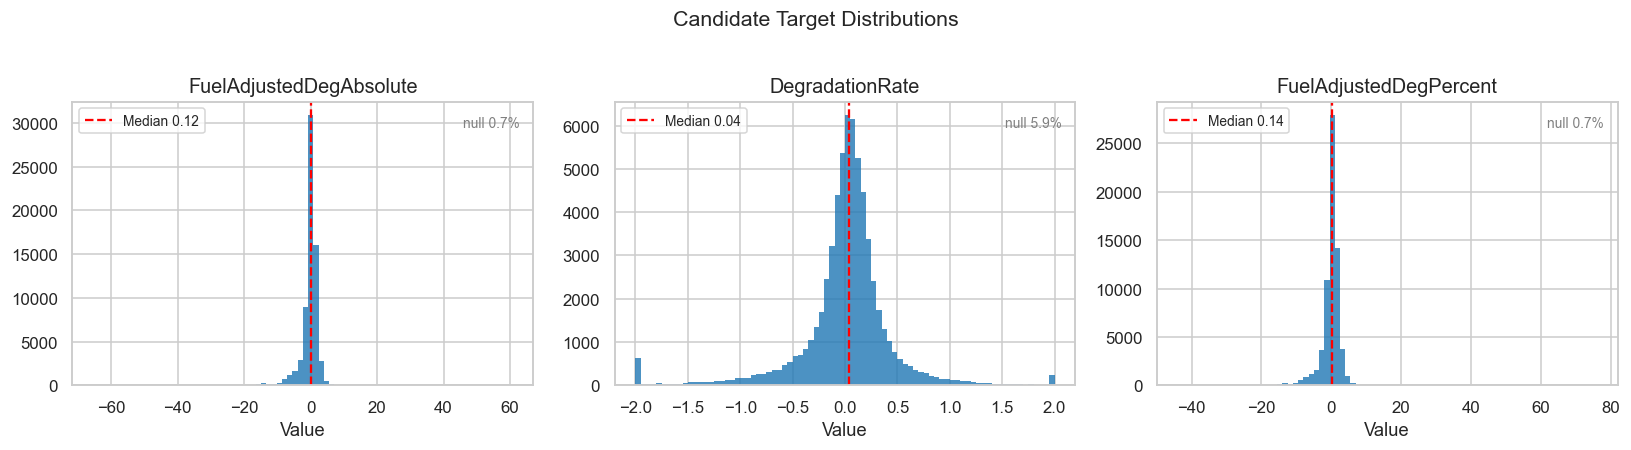

── FuelAdjustedDegAbsolute — descriptive stats ──
count    67636.000
mean        -0.688
std          5.287
min        -65.346
25%         -0.756
50%          0.121
75%          0.995
max         60.713

Skewness : -7.027  |  Kurtosis : 62.666
Negative values: 41.1%  (expected: warm-up phase on first 1–2 laps)


In [4]:
def plot_target_distributions(df: pd.DataFrame, outputs_path: Path) -> None:
    """Distribution and outlier analysis of candidate target variables."""
    targets = ['FuelAdjustedDegAbsolute', 'DegradationRate', 'FuelAdjustedDegPercent']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, targets):
        data = df[col].dropna()
        ax.hist(data, bins=80, edgecolor='none', alpha=0.8)
        ax.axvline(data.median(), color='red', linestyle='--', label=f'Median {data.median():.2f}')
        ax.set_title(col)
        ax.set_xlabel('Value')
        ax.legend(fontsize=9)
        # Annotate null rate
        ax.text(0.97, 0.95, f'null {df[col].isna().mean():.1%}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9, color='grey')

    fig.suptitle('Candidate Target Distributions', y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig(outputs_path / 'target_distributions.png', bbox_inches='tight')
    plt.show()


def describe_target(df: pd.DataFrame) -> None:
    """Print descriptive stats for the selected target."""
    col = 'FuelAdjustedDegAbsolute'
    print(f'── {col} — descriptive stats ──')
    print(df[col].describe().round(3).to_string())
    skew = df[col].dropna().skew()
    kurt = df[col].dropna().kurt()
    print(f'\nSkewness : {skew:.3f}  |  Kurtosis : {kurt:.3f}')
    neg_pct = (df[col] < 0).mean()
    print(f'Negative values: {neg_pct:.1%}  (expected: warm-up phase on first 1–2 laps)')


# ── Run ──
plot_target_distributions(df, outputs_path)
describe_target(df)

### Step 2 — Observations

**FuelAdjustedDegAbsolute** is the selected target. Key takeaways from the distribution:

- **Median 0.12 s, mean −0.688 s** — the distribution is centered near zero but the mean is pulled left by large negative outliers (extreme SC/VSC laps where fuel-adjusted time drops sharply below the stint baseline).
- **41.1% negative values** — significantly more than the 1–2 lap warm-up phase would explain. Negative deg occurs throughout the first several laps as tires reach optimal operating temperature, and also during safety car periods where lap time plummets independently of tire wear. These are physically valid, not artefacts.
- **Skewness −7.0 / Kurtosis 62.7** — very heavy tails in both directions (min −65 s, max +61 s). Standard MSE loss in N08 will be dominated by these extremes → **Huber loss** preferred for the TCN.
- **DegradationRate** is tightly concentrated around 0 (median 0.04 s/lap) with hard clips at ±2 s/lap (applied in N04). The small spike visible near −2 indicates some stints genuinely hit the degradation cliff boundary.
- **FuelAdjustedDegPercent** mirrors FuelAdjustedDegAbsolute in shape (it is simply normalized by the stint baseline). No additional information — confirmed redundant as a candidate target.

**Implication for N08:** the TCN must handle outliers robustly. Consider clipping the target to a sensible strategic range (e.g. −5 s to +10 s) before training, or using a robust loss function. The 41% negative proportion also means the model needs to learn the warm-up curve, not just the degradation curve — this is a feature, not a bug: predicting the full stint trajectory including the initial improvement phase is strategically valuable.


## Step 3 — Absolute Compound Analysis

This is the key new information compared to N02/N05, which only saw relative labels (SOFT/MEDIUM/HARD).

Questions:
- How is each absolute compound distributed across circuits and years?
- Does the same compound (e.g. C3) produce a different degradation profile depending on whether it was nominated as HARD, MEDIUM, or SOFT?

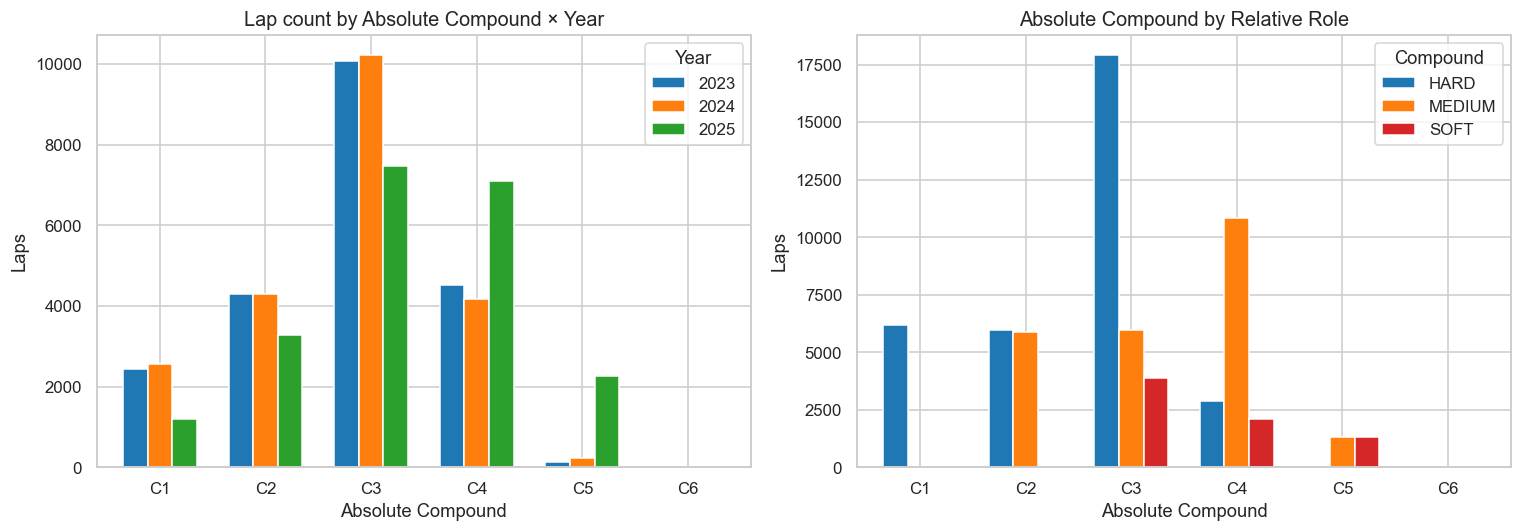

── Absolute Compound × Relative Role (lap counts) ──
Compound           HARD  MEDIUM  SOFT
AbsoluteCompound                     
C1                 6188       0     0
C2                 5963    5896     0
C3                17899    5983  3872
C4                 2891   10821  2089
C5                    0    1315  1308
C6                    0       0    46


In [5]:
def plot_absolute_compound_distribution(df: pd.DataFrame, outputs_path: Path) -> None:
    """Lap counts by absolute compound per year and role."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: count by compound × year
    ct = df.groupby(['Year', 'AbsoluteCompound']).size().unstack('Year', fill_value=0)
    ct.plot(kind='bar', ax=axes[0], width=0.7)
    axes[0].set_title('Lap count by Absolute Compound × Year')
    axes[0].set_xlabel('Absolute Compound')
    axes[0].set_ylabel('Laps')
    axes[0].tick_params(axis='x', rotation=0)

    # Right: compound × relative role (SOFT/MEDIUM/HARD)
    ct2 = (
        df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
        .groupby(['AbsoluteCompound', 'Compound'])
        .size()
        .unstack('Compound', fill_value=0)
    )
    ct2 = ct2[['HARD', 'MEDIUM', 'SOFT']]   # order by hardness
    ct2.plot(kind='bar', ax=axes[1], width=0.7, color=['#1f77b4', '#ff7f0e', '#d62728'])
    axes[1].set_title('Absolute Compound by Relative Role')
    axes[1].set_xlabel('Absolute Compound')
    axes[1].set_ylabel('Laps')
    axes[1].tick_params(axis='x', rotation=0)

    fig.tight_layout()
    fig.savefig(outputs_path / 'absolute_compound_distribution.png', bbox_inches='tight')
    plt.show()


def print_compound_role_matrix(df: pd.DataFrame) -> None:
    """Cross-tab of absolute compound vs relative role. Should be sparse (each circuit
    nominates 3 consecutive compounds, so each absolute compound appears in at most 3 roles)."""
    ct = pd.crosstab(df['AbsoluteCompound'], df['Compound'])
    # Reorder columns
    col_order = [c for c in ['HARD', 'MEDIUM', 'SOFT', 'INTERMEDIATE', 'WET', 'UNKNOWN'] if c in ct.columns]
    print('── Absolute Compound × Relative Role (lap counts) ──')
    print(ct[col_order].to_string())


# ── Run ──
plot_absolute_compound_distribution(df, outputs_path)
print_compound_role_matrix(df)

### Step 3 — Observations

**Lap count by compound × year:**
- C6 only appears in 2025 across a handful of races, barely visible in the chart.
- C5 usage increases notably in 2025 compared to prior seasons.
- 2023 and 2024 leaned towards harder compounds (C1–C3), which translated into
  fewer pit stops and slower, more gradual degradation curves.

**Absolute compound × relative role:**
- C1 and C6, being the hardest and softest compounds respectively, appear exclusively
  as HARD and SOFT — they have no other viable role.
- C3 is by far the most used compound overall, owing to its intermediate degradation
  characteristics: it was nominated as HARD at demanding circuits that stress tyres heavily,
  and as SOFT at more tyre-friendly circuits. This versatility explains why it dominates
  all three role columns.
- C4 follows a similar pattern but is predominantly used as MEDIUM.


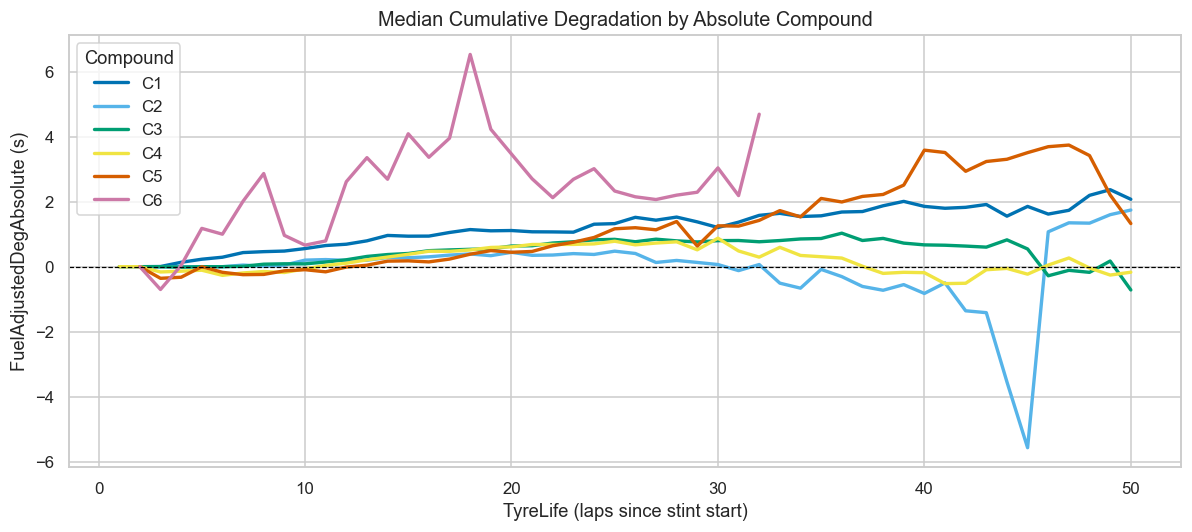

── Degradation stats by absolute compound ──
                   laps  mean_deg  deg_at_lap10  deg_at_lap20  deg_rate_mean
AbsoluteCompound                                                            
C1                 6171     0.407         0.244         0.567          0.060
C2                11859    -0.463        -0.090        -0.122          0.017
C3                27754    -0.259        -0.407         0.050          0.029
C4                15799    -1.243        -1.186        -1.094          0.015
C5                 2623    -0.080        -0.364        -0.120          0.003
C6                   46     1.913         0.663           NaN          0.131


In [6]:
def plot_deg_by_absolute_compound(df: pd.DataFrame, outputs_path: Path) -> None:
    """Median degradation curve (FuelAdjustedDegAbsolute vs TyreLife) per absolute compound.
    This is the core justification for the per-compound modelling strategy."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna() &
        df['FuelAdjustedDegAbsolute'].notna() &
        (df['TyreLife'] <= 50)
    ].copy()

    palette = {'C1': '#0072B2', 'C2': '#56B4E9', 'C3': '#009E73',
               'C4': '#F0E442', 'C5': '#D55E00', 'C6': '#CC79A7'}

    fig, ax = plt.subplots(figsize=(11, 5))
    for compound, grp in dry.groupby('AbsoluteCompound'):
        med = grp.groupby('TyreLife')['FuelAdjustedDegAbsolute'].median()
        ax.plot(med.index, med.values, label=compound,
                color=palette.get(compound, 'grey'), linewidth=2.2)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Median Cumulative Degradation by Absolute Compound')
    ax.set_xlabel('TyreLife (laps since stint start)')
    ax.set_ylabel('FuelAdjustedDegAbsolute (s)')
    ax.legend(title='Compound', loc='upper left')
    fig.tight_layout()
    fig.savefig(outputs_path / 'deg_by_absolute_compound.png', bbox_inches='tight')
    plt.show()


def print_compound_deg_stats(df: pd.DataFrame) -> None:
    """Mean deg at TyreLife=20 by compound, as a quick degradation ranking."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna() &
        df['FuelAdjustedDegAbsolute'].notna()
    ]
    stats_df = dry.groupby('AbsoluteCompound').agg(
        laps=('FuelAdjustedDegAbsolute', 'count'),
        mean_deg=('FuelAdjustedDegAbsolute', 'mean'),
        deg_at_lap10=('FuelAdjustedDegAbsolute',
                      lambda x: x[dry.loc[x.index, 'TyreLife'] == 10].mean()),
        deg_at_lap20=('FuelAdjustedDegAbsolute',
                      lambda x: x[dry.loc[x.index, 'TyreLife'] == 20].mean()),
        deg_rate_mean=('DegradationRate', 'mean'),
    ).round(3)
    print('── Degradation stats by absolute compound ──')
    print(stats_df.to_string())


# ── Run ──
plot_deg_by_absolute_compound(df, outputs_path)
print_compound_deg_stats(df)

### Step 3 — Observations (degradation curves)

- **C1** is the only compound with positive mean degradation (0.407 s, rate 0.060 s/lap),
  consistently accumulating wear across long stints on demanding circuits.
- **C2–C5 show negative mean degradation** — the warm-up improvement phase dominates
  over typical stint lengths for softer compounds. The fuel correction constant (0.055 s/lap)
  may also slightly overcorrect for these compounds.
- **C2 below lap 45** dives anomalously to −5 s: a low-sample artefact, not real degradation.
- **C6** (46 laps, 2025 only) is statistically unreliable — spikes in the curve should not
  be interpreted as real patterns.
- The model must learn both phases of a stint: the initial warm-up (negative deg) and
  the subsequent wear ramp-up.


## Step 4 — Temporal Structure (TCN Input Design)

A TCN operates on fixed-length sequences. We need to understand:
1. **Stint length distribution** → determines window size for N08
2. **Autocorrelation** → confirms temporal dependency (justifies TCN over MLP)
3. **Stationarity** → informs whether to feed raw values or differences to the TCN

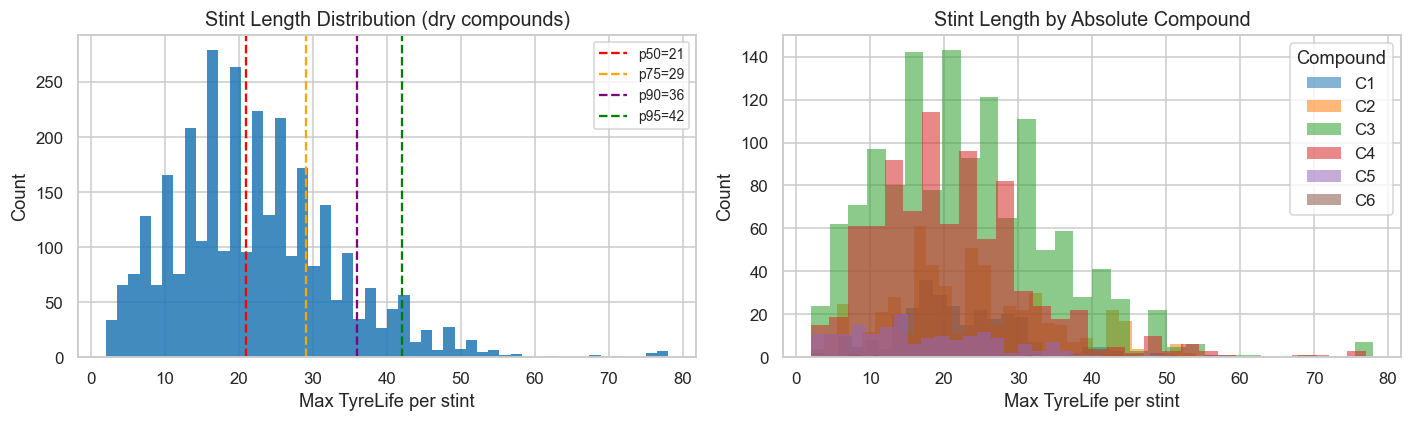

── Stint length percentiles ──
count    3220.0
mean       22.2
std        11.1
min         2.0
50%        21.0
75%        29.0
90%        36.0
95%        42.0
99%        52.0
max        78.0


In [7]:
def plot_stint_length_distribution(df: pd.DataFrame, outputs_path: Path) -> pd.DataFrame:
    """Distribution of dry-compound stint lengths. Determines TCN max sequence length."""
    dry = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
    stint_lengths = (
        dry.groupby(['Year', 'GP_Name', 'DriverNumber', 'Stint'])['TyreLife'].max()
        .reset_index(name='max_tyrelife')
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Overall distribution
    axes[0].hist(stint_lengths['max_tyrelife'], bins=50, edgecolor='none', alpha=0.85)
    for p, c in [(50, 'red'), (75, 'orange'), (90, 'purple'), (95, 'green')]:
        v = stint_lengths['max_tyrelife'].quantile(p / 100)
        axes[0].axvline(v, color=c, linestyle='--', label=f'p{p}={v:.0f}')
    axes[0].set_title('Stint Length Distribution (dry compounds)')
    axes[0].set_xlabel('Max TyreLife per stint')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=9)

    # By compound
    for compound, grp in stint_lengths.merge(
        dry[['Year', 'GP_Name', 'DriverNumber', 'Stint', 'AbsoluteCompound']].drop_duplicates(),
        on=['Year', 'GP_Name', 'DriverNumber', 'Stint']
    ).groupby('AbsoluteCompound'):
        axes[1].hist(grp['max_tyrelife'], bins=30, alpha=0.55, label=compound, edgecolor='none')
    axes[1].set_title('Stint Length by Absolute Compound')
    axes[1].set_xlabel('Max TyreLife per stint')
    axes[1].set_ylabel('Count')
    axes[1].legend(title='Compound')

    fig.tight_layout()
    fig.savefig(outputs_path / 'stint_length_distribution.png', bbox_inches='tight')
    plt.show()

    print('── Stint length percentiles ──')
    print(stint_lengths['max_tyrelife'].describe(percentiles=[.5, .75, .90, .95, .99]).round(1).to_string())
    return stint_lengths


# ── Run ──
stint_lengths = plot_stint_length_distribution(df, outputs_path)

### Step 4 — Observations (stint length)

- **Median stint: 21 laps**, p75 = 29, p90 = 36, p95 = 42.
  The max of 78 laps corresponds to the Monaco 2024 one-stop race, where most drivers pitted in lap 1–2 and completed the remainder of the race on a single set — a valid extreme case, not an artefact.
- The distribution is roughly bimodal, with peaks around laps 17–20 and a second cluster around 25–30, reflecting the two dominant F1 strategies (1-stop and 2-stop).
- **C3 dominates mid-range stints** (15–35 laps) given its volume. **C1** extends further right, consistent with very long opening stints on hard tyres. **C4/C5** cluster at shorter lengths, as softer compounds are pitted earlier.

**Global window size: 36 laps (p90)**

p90 = 36 covers 90% of stints without truncation. Going to p95 = 42 would reduce truncation by only 5 percentage points while increasing padding overhead significantly for the majority of stints (median = 21 laps). 36 sits comfortably above both modal peaks (17–20 and 25–30) and ensures the TCN has enough context for all common strategies.

This value is used directly as `GLOBAL_WINDOW_SIZE` in N09 for the ablation study (global model production vs pure). Stints longer than 36 laps are truncated from the start — the most recent 36 laps are the strategically relevant portion.

Per-compound window sizes are computed analytically in **N08_tiredeg_sequence_config.ipynb** from the same data and used only by the per-compound fine-tuned models.

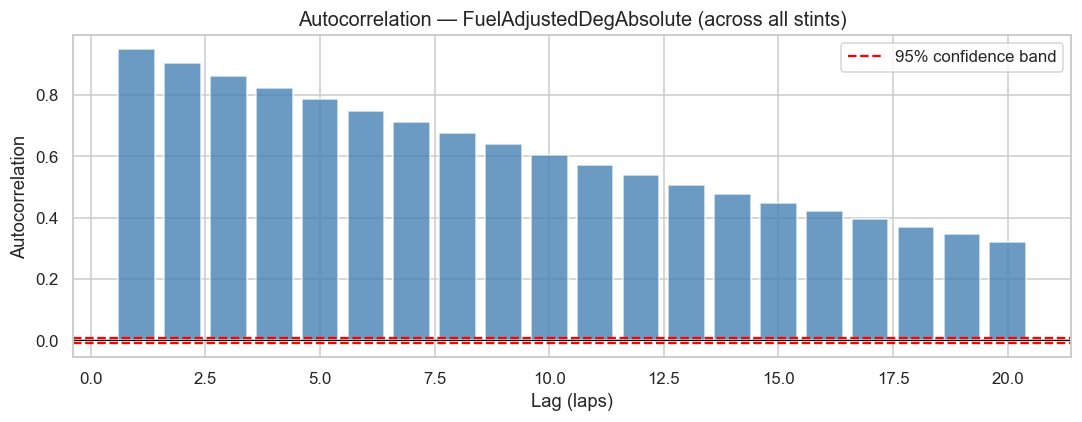

── ADF stationarity test (p < 0.05 → stationary) ──
                    stint  length  adf_stat  p_value  stationary
 (2023, 'Austin', 1, 1.0)      14    -2.287   0.1763       False
 (2023, 'Austin', 2, 1.0)       9    -2.215   0.2010       False
 (2023, 'Austin', 3, 1.0)      20    -1.043   0.7373       False
 (2023, 'Austin', 4, 1.0)      14    -2.226   0.1971       False
(2023, 'Austin', 10, 1.0)      16     0.287   0.9768       False


In [8]:
def plot_autocorrelation(df: pd.DataFrame, outputs_path: Path, max_lag: int = 20) -> None:
    """ACF of FuelAdjustedDegAbsolute within stints. High autocorrelation justifies TCN."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['FuelAdjustedDegAbsolute'].notna()
    ].sort_values(['Year', 'GP_Name', 'DriverNumber', 'Stint', 'TyreLife'])

    # Compute autocorrelation across all stints (treating them as one long series)
    series = dry['FuelAdjustedDegAbsolute'].values
    acf_vals = [pd.Series(series).autocorr(lag=l) for l in range(1, max_lag + 1)]

    fig, ax = plt.subplots(figsize=(10, 4))
    lags = list(range(1, max_lag + 1))
    ax.bar(lags, acf_vals, color='steelblue', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(1.96 / np.sqrt(len(series)), color='red',
               linestyle='--', label='95% confidence band')
    ax.axhline(-1.96 / np.sqrt(len(series)), color='red', linestyle='--')
    ax.set_title('Autocorrelation — FuelAdjustedDegAbsolute (across all stints)')
    ax.set_xlabel('Lag (laps)')
    ax.set_ylabel('Autocorrelation')
    ax.legend()
    fig.tight_layout()
    fig.savefig(outputs_path / 'autocorrelation_deg.png', bbox_inches='tight')
    plt.show()


def test_stationarity(df: pd.DataFrame, sample_n: int = 5) -> None:
    """ADF stationarity test on a sample of individual stints.
    Non-stationary stints → feed differences (ΔDeg per lap) to TCN rather than absolute values."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['FuelAdjustedDegAbsolute'].notna()
    ].sort_values(['Year', 'GP_Name', 'DriverNumber', 'Stint', 'TyreLife'])

    groups = dry.groupby(['Year', 'GP_Name', 'DriverNumber', 'Stint'])
    sampled = list(groups)[:sample_n * 3:3]  # spread sample

    print('── ADF stationarity test (p < 0.05 → stationary) ──')
    results = []
    for name, grp in sampled:
        series = grp['FuelAdjustedDegAbsolute'].values
        if len(series) < 5:
            continue
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        results.append({'stint': str(name), 'length': len(series),
                        'adf_stat': round(adf_stat, 3), 'p_value': round(p_val, 4),
                        'stationary': p_val < 0.05})
    print(pd.DataFrame(results).to_string(index=False))


# ── Run ──
plot_autocorrelation(df, outputs_path)
test_stationarity(df)

### Step 4 — Observations (autocorrelation & stationarity)

**Autocorrelation:**
- Lag-1 autocorrelation ~0.95, decaying slowly to ~0.32 at lag 20 — all values remain
  far above the 95% confidence band throughout.
- This persistent autocorrelation is expected: `FuelAdjustedDegAbsolute` is a cumulative
  variable that tends to grow monotonically within a stint.
- **Strong temporal dependency confirmed → TCN is the right architecture** over any
  non-sequential model (XGBoost, MLP).

**Stationarity (ADF test):**
- All sampled stints are non-stationary (p >> 0.05), again consistent with a cumulative
  target that trends upward over time.

**Implication for N08:** feed the TCN input sequence using rates and differences
(`DegradationRate`, lap-to-lap deltas) rather than raw cumulative values, which are
non-stationary. The target `FuelAdjustedDegAbsolute` can remain cumulative — the model
predicts the absolute level, but its inputs should be stationary. LayerNorm inside each
TCN block will also help absorb residual non-stationarity.


## Step 5 — Degradation Cliff Detection

A tire 'cliff' is the point at which wear accelerates rapidly. Identifying when cliffs occur — by compound and circuit type — is critical for strategy (pit window decisions). We look for it in `DegradationRate` acceleration and in per-stint curve shapes.

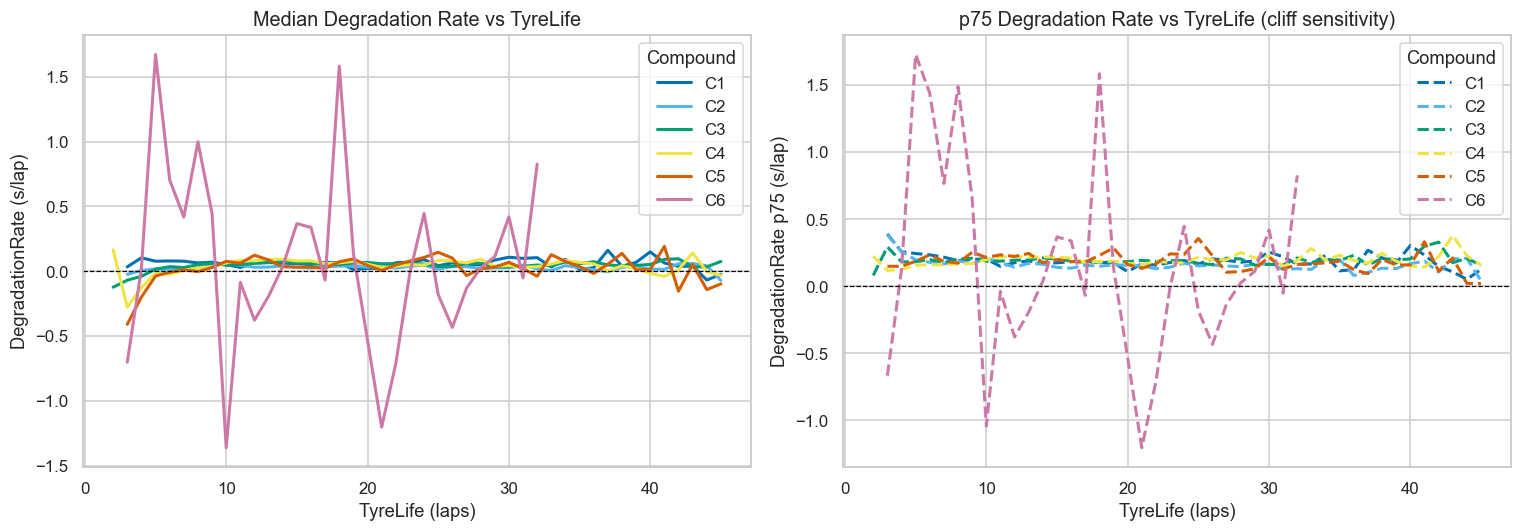

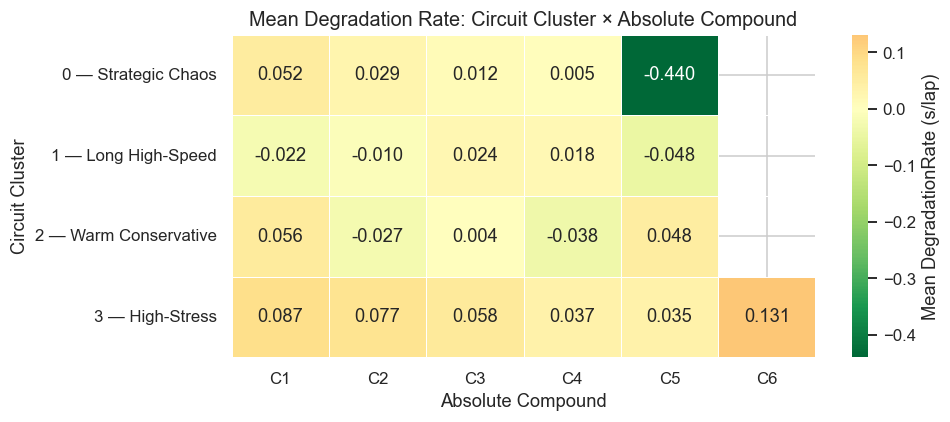

In [9]:
def plot_degradation_rate_by_tyrelife(df: pd.DataFrame, outputs_path: Path) -> None:
    """Median DegradationRate vs TyreLife per absolute compound.
    Cliff = TyreLife where median DegradationRate spikes upward."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna() &
        df['DegradationRate'].notna() &
        (df['TyreLife'] <= 45)
    ]

    palette = {'C1': '#0072B2', 'C2': '#56B4E9', 'C3': '#009E73',
               'C4': '#F0E442', 'C5': '#D55E00', 'C6': '#CC79A7'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: median degradation rate per compound
    for compound, grp in dry.groupby('AbsoluteCompound'):
        med = grp.groupby('TyreLife')['DegradationRate'].median()
        axes[0].plot(med.index, med.values, label=compound,
                     color=palette.get(compound, 'grey'), linewidth=2)
    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Median Degradation Rate vs TyreLife')
    axes[0].set_xlabel('TyreLife (laps)')
    axes[0].set_ylabel('DegradationRate (s/lap)')
    axes[0].legend(title='Compound')

    # Right: p75 degradation rate (shows when cliff starts for most stints)
    for compound, grp in dry.groupby('AbsoluteCompound'):
        p75 = grp.groupby('TyreLife')['DegradationRate'].quantile(0.75)
        axes[1].plot(p75.index, p75.values, label=compound,
                     color=palette.get(compound, 'grey'), linewidth=2, linestyle='--')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('p75 Degradation Rate vs TyreLife (cliff sensitivity)')
    axes[1].set_xlabel('TyreLife (laps)')
    axes[1].set_ylabel('DegradationRate p75 (s/lap)')
    axes[1].legend(title='Compound')

    fig.tight_layout()
    fig.savefig(outputs_path / 'degradation_rate_by_tyrelife.png', bbox_inches='tight')
    plt.show()


def plot_cluster_compound_interaction(df: pd.DataFrame, outputs_path: Path) -> None:
    """Heatmap: mean DegradationRate by Cluster × AbsoluteCompound.
    Answers: does C3 degrade faster at high-speed circuits (Cluster 1) than at street circuits (Cluster 3)?"""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna() &
        df['DegradationRate'].notna() &
        df['Cluster'].notna()
    ]

    cluster_names = {
        0: '0 — Strategic Chaos',
        1: '1 — Long High-Speed',
        2: '2 — Warm Conservative',
        3: '3 — High-Stress'
    }
    dry = dry.copy()
    dry['Cluster_name'] = dry['Cluster'].map(cluster_names)

    pivot = dry.groupby(['Cluster_name', 'AbsoluteCompound'])['DegradationRate'].mean().unstack()

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean DegradationRate (s/lap)'})
    ax.set_title('Mean Degradation Rate: Circuit Cluster × Absolute Compound')
    ax.set_xlabel('Absolute Compound')
    ax.set_ylabel('Circuit Cluster')
    fig.tight_layout()
    fig.savefig(outputs_path / 'cluster_compound_interaction.png', bbox_inches='tight')
    plt.show()


# ── Run ──
plot_degradation_rate_by_tyrelife(df, outputs_path)
plot_cluster_compound_interaction(df, outputs_path)

### Step 5 — Observations (cliff detection & circuit interaction)

**Degradation rate vs TyreLife:**
- C1–C5 remain very close to 0 s/lap across the entire TyreLife range — no visible cliff
  emerges in the aggregate median. Degradation is gradual and distributed, not concentrated
  at a specific lap number.
- The p75 plot confirms this: even at the 75th percentile, C1–C5 stay below 0.25 s/lap.
  The cliff, when it occurs, is a circuit- and condition-specific event — invisible when
  averaged across all races.
- **C6 (pink) is noise** — 46 laps total, ignore entirely.
- **Implication:** the TCN cannot learn a universal cliff lap from aggregate data.
  It will need to infer cliff risk from the combination of compound, circuit cluster,
  track temperature, and stint history — exactly what a sequence model is suited for.

**Heatmap — Circuit Cluster × Absolute Compound:**
- **Cluster 3 (High-Stress)** shows the highest degradation rates across every compound
  (C1=0.087, C2=0.077, C3=0.058 s/lap), confirming that street and high-downforce
  circuits consume tyres faster regardless of compound choice.
- **Cluster 1 (Long High-Speed)** shows near-zero or negative values — high-speed circuits
  like Monza produce lower fuel-adjusted deg, as aero-efficient cars on long straights
  stress the rubber less laterally.
- **C5 at Cluster 0 (−0.440)** is a low-sample artefact, not a real pattern.
- **Implication:** `Cluster` is a meaningful feature for the TCN — the same compound
  degrades at meaningfully different rates depending on circuit type.


## Step 6 — Feature–Target Correlations for Degradation

Unlike N05 (which correlated features with `LapTime_s`), here we correlate with `FuelAdjustedDegAbsolute`. Weather, track characteristics, and tire identity should dominate.

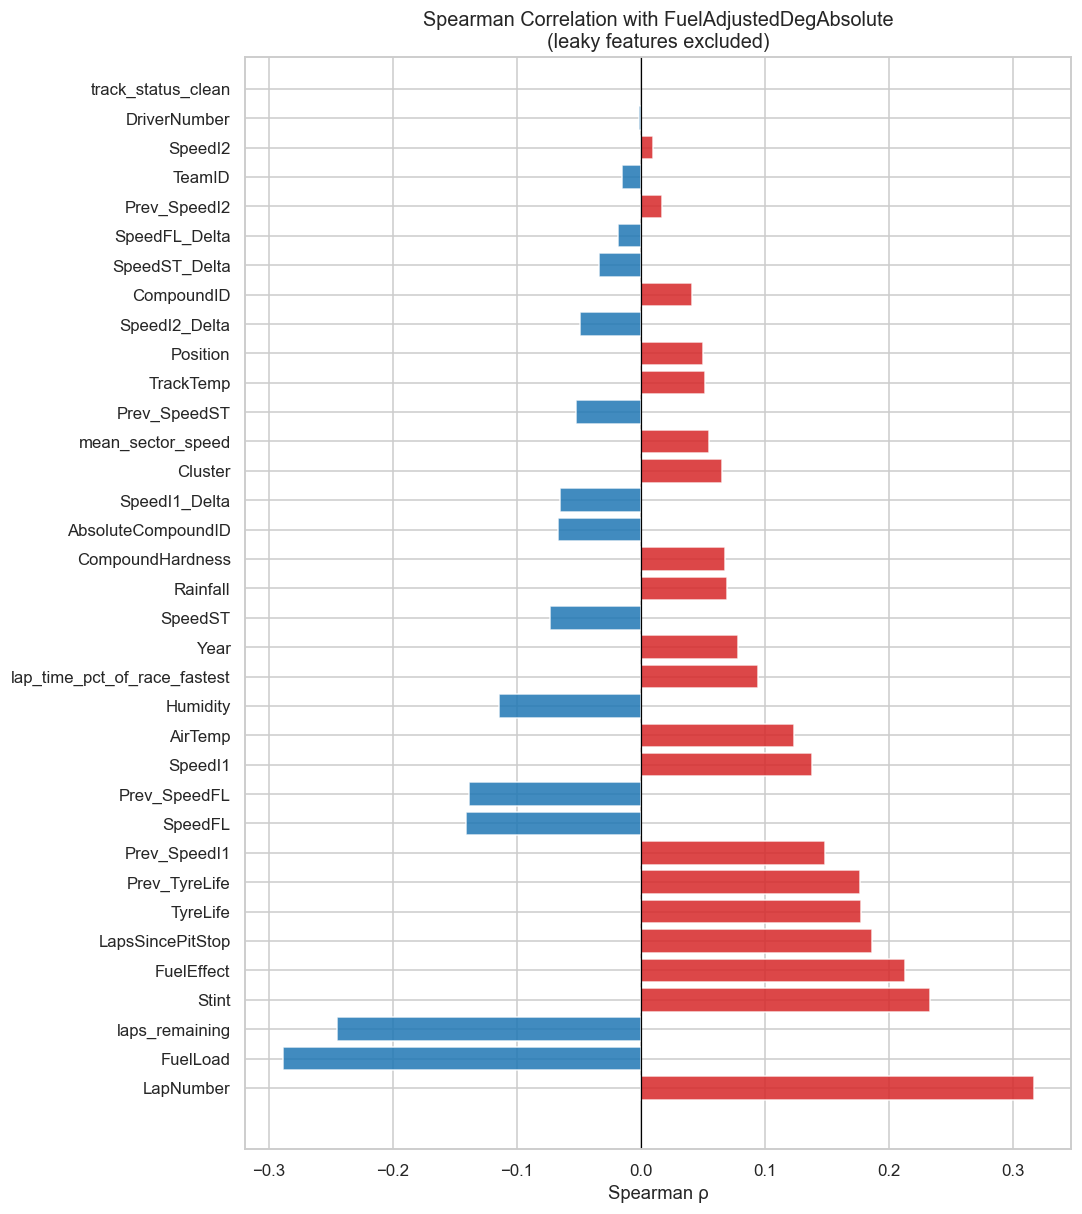

LapNumber                       0.316
FuelLoad                       -0.289
laps_remaining                 -0.245
Stint                           0.233
FuelEffect                      0.212
LapsSincePitStop                0.186
TyreLife                        0.177
Prev_TyreLife                   0.176
Prev_SpeedI1                    0.148
SpeedFL                        -0.141
Prev_SpeedFL                   -0.139
SpeedI1                         0.138
AirTemp                         0.123
Humidity                       -0.114
lap_time_pct_of_race_fastest    0.094
Year                            0.078
SpeedST                        -0.074
Rainfall                        0.069
CompoundHardness                0.067
AbsoluteCompoundID             -0.067
SpeedI1_Delta                  -0.066
Cluster                         0.065
mean_sector_speed               0.055
Prev_SpeedST                   -0.053
TrackTemp                       0.052
Position                        0.050
SpeedI2_Delt

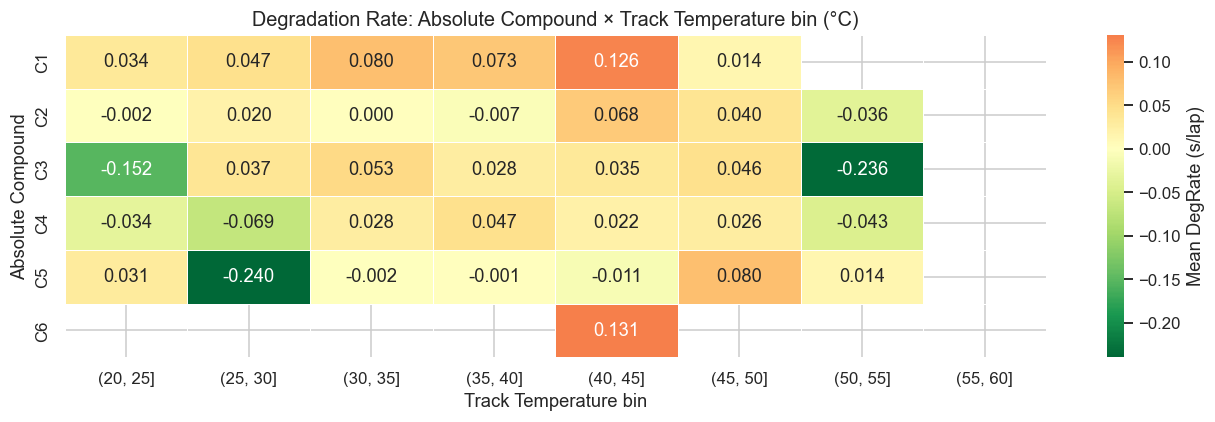

In [10]:
def plot_feature_correlations_with_deg(df: pd.DataFrame, outputs_path: Path) -> pd.Series:
    """Spearman correlations of all numeric features with FuelAdjustedDegAbsolute."""
    target = 'FuelAdjustedDegAbsolute'

    # Exclude leaky and non-numeric columns (defined in Step 7)
    leaky = {
        'LapTime_s', 'FuelAdjustedLapTime', 'FuelAdjustedDegPercent',
        'CumulativeDeg', 'DegradationRate', 'DegAcceleration',
        'LapTime_Delta', 'Prev_LapTime', 'LapTime_Trend',
        'lap_time_vs_cluster_mean', 'delta_vs_year_circuit_median',
        'Sector1_s', 'Sector2_s', 'Sector3_s',
        target
    }

    numeric_cols = [
        c for c in df.select_dtypes(include='number').columns
        if c not in leaky and df[c].notna().sum() > 1000
    ]

    corrs = df[numeric_cols + [target]].dropna().corr(method='spearman')[target].drop(target)
    corrs = corrs.sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(corrs) * 0.32)))
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in corrs.values]
    ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Spearman Correlation with {target}\n(leaky features excluded)')
    ax.set_xlabel('Spearman ρ')
    fig.tight_layout()
    fig.savefig(outputs_path / 'feature_correlations_with_deg.png', bbox_inches='tight')
    plt.show()

    print(corrs.round(3).to_string())
    return corrs


def plot_weather_compound_deg(df: pd.DataFrame, outputs_path: Path) -> None:
    """TrackTemp × AbsoluteCompound interaction on degradation rate.
    Softer compounds are expected to be more sensitive to high track temperatures."""
    dry = df[
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        df['AbsoluteCompound'].notna() &
        df['DegradationRate'].notna() &
        df['TrackTemp'].notna()
    ]

    # Bin TrackTemp into 5°C buckets
    dry = dry.copy()
    dry['TrackTemp_bin'] = pd.cut(dry['TrackTemp'], bins=range(20, 65, 5))

    pivot = dry.groupby(['AbsoluteCompound', 'TrackTemp_bin'])['DegradationRate'].mean().unstack()

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean DegRate (s/lap)'})
    ax.set_title('Degradation Rate: Absolute Compound × Track Temperature bin (°C)')
    ax.set_xlabel('Track Temperature bin')
    ax.set_ylabel('Absolute Compound')
    fig.tight_layout()
    fig.savefig(outputs_path / 'weather_compound_deg.png', bbox_inches='tight')
    plt.show()


# ── Run ──
corrs = plot_feature_correlations_with_deg(df, outputs_path)
plot_weather_compound_deg(df, outputs_path)

### Step 6 — Observations (feature correlations with degradation)

**What Spearman correlation measures here:**
Spearman ρ quantifies the monotonic relationship between each feature and `FuelAdjustedDegAbsolute` — i.e., whether higher values of the feature tend to go with more degradation, regardless of linearity. It is more robust than Pearson for skewed distributions like ours (skew −7, kurtosis 63). Values range from −1 (perfect inverse) to +1 (perfect direct). Correlations below ±0.1 are considered negligible for this sample size.

**Strongest positive correlators (deg increases with these):**
- **LapNumber (0.316)** — the single strongest signal. Deeper into the race = more wear accumulated. This is partly definitional (deg is cumulative), but it also reflects real progressive tire degradation.
- **Stint (0.233)** and **LapsSincePitStop (0.186)** — capture the same race-phase effect via different encodings. Later stints and more laps on the current set both correspond to more accumulated deg.
- **FuelEffect (0.212)** — FuelEffect = (TyreLife − 1) × 0.055, so it grows with TyreLife. Its correlation with the target confirms that the fuel-correction term is well-aligned with tire age dynamics.
- **TyreLife (0.177)** — direct tire age; correlated but lower than LapNumber because TyreLife resets at each pit stop (same car can have TyreLife=5 in lap 40 after a late-race pit).

**Strongest negative correlators (deg decreases with these):**
- **FuelLoad (−0.289)** — inversely proportional to LapNumber (FuelLoad = 1 − LapNumber/MaxLap), so this mirrors the LapNumber effect. Both features encode race progress; keep one or the other, not both, in the TCN input to avoid redundancy.
- **laps_remaining (−0.245)** — same reasoning: fewer laps remaining → deeper into the race → more wear.
- **SpeedFL (−0.141)** — finish-line trap speed is faster early in the race (light fuel, fresh tires). Negative correlation is expected; it's a weak proxy for race phase.

**Weather features:**
- **AirTemp (0.123)** — warmer air mildly increases degradation, consistent with thermal runway effects on soft rubber.
- **Humidity (−0.114)** — higher humidity correlates with slightly lower deg, possibly because humid conditions reduce track abrasiveness.
- **TrackTemp (0.052)** — surprisingly weak given its physical importance. TrackTemp varies strongly within a race session and is confounded by cloud cover changes; the within-stint variation is low, which suppresses the correlation.

**Tire identity features:**
- **AbsoluteCompoundID (−0.067)** and **CompoundHardness (0.067)** are symmetric by construction (Hardness = 7 − ID). The magnitude is low because harder compounds run longer stints, partially offsetting their naturally lower wear rate when correlated across all laps.
- **Cluster (0.065)** — weak but present; `Cluster 3 — High-Stress` does produce more deg (as seen in Step 5), but the signal is diluted across the full dataset.

**Heatmap — Compound × Track Temperature:**
- **C1** is the only compound with a clear positive temperature trend: 0.034 s/lap at (20–25°C] rising to 0.126 s/lap at (40–45°C]. This is counterintuitive since C1 is the hardest compound — the explanation is confounding: C1 is allocated to thermally demanding circuits (Bahrain, Barcelona, Silverstone), so high track temps co-occur with circuits that stress tires heavily regardless of rubber hardness.
- **C2** is flat across all bins, consistently near zero. No meaningful temperature sensitivity.
- **C3** shows −0.152 at (20–25°C] and −0.236 at (50–55°C] — both are low-sample artefacts at temperature extremes, not real patterns. The mid-range bins (30–50°C) are stable around 0.02–0.05 s/lap.
- **C4** is near zero or slightly negative across most bins — no consistent temperature relationship.
- **C5** shows −0.240 at (25–30°C], which is a clear artefact (very few C5 laps in cold conditions); the remaining bins cluster near zero, with a mild 0.080 at (45–50°C].
- **C6** has a single data point (0.131 at 40–45°C]) — statistically meaningless.

The expected physics (softer compounds more temperature-sensitive) does not emerge cleanly from this data because **compound choice and circuit type are correlated**: softer compounds are allocated to milder circuits (where track temps stay lower), masking their intrinsic heat sensitivity. This confounding is a known limitation of observational race data. TrackTemp should still be included as a TCN input — its effect is likely real but requires the model to condition on compound identity simultaneously to resolve it.

**Implication for N08:** race-phase features (LapNumber, laps_remaining, FuelLoad, Stint) are redundant with each other — use at most one in the TCN. `TyreLife` is the most direct and interpretable, with no redundancy risk. Weather features (AirTemp, Humidity) are weak individually but may help the model generalise across circuit types when combined. `Cluster` should be included as a categorical embedding rather than a raw integer.

## Step 7 — Leakage Audit for the Degradation Target

**Target:** `FuelAdjustedDegAbsolute` = cumulative seconds lost to tire wear since stint start.

After verifying how every feature is computed in N04 and confirming availability at inference time (end of lap t), the leakage analysis is structured into three categories:

> **Key principle:** for a causal model predicting lap t+1, any feature available at the end of lap t is temporally valid — it does not use future data. The only genuinely leaky features are those that **directly encode the current-step target value**.

---

### Category 1 — Truly Leaky (drop in ALL models)

| Feature | Why leaky | Computation |
|---------|-----------|-------------|
| `FuelAdjustedDegAbsolute` | **IS the target** | `FuelAdjustedLapTime − baseline_lap` |
| `CumulativeDeg` | Identical to target (different name, same value) | same |
| `FuelAdjustedDegPercent` | Monotonic transformation of target | `(FuelAdjustedLapTime / baseline − 1) × 100` |
| `FuelAdjustedLapTime` | Encodes target directly: `target[t] = FuelAdjustedLapTime[t] − baseline` | `LapTime_s + (TyreLife−1) × 0.055` |

---

### Category 2 — Valid at Inference Time, Excluded Only from the Pure Model

These features are **computable at the end of lap t** from real-time telemetry — they are not temporally leaky. However, they carry implicit information about the current degradation state through lap time. Including them allows the model to learn a shortcut (`deg[t+1] ≈ deg[t] + rate`) rather than learning from physical causes.

| Feature | Computation (N04) | Production | Pure (TFG) |
|---------|-------------------|:----------:|:-----------:|
| `LapTime_s` | `LapTime.dt.total_seconds()` | ✓ | ✗ |
| `DegradationRate` | Rolling 3-lap polyfit slope of `FuelAdjustedLapTime` vs `TyreLife` (clipped ±2 s/lap) | ✓ | ✗ |
| `DegAcceleration` | `DegradationRate[t] − DegradationRate[t−1]` | ✓ | ✗ |
| `LapTime_Delta` | `LapTime_s[t] − LapTime_s[t−1]` | ✓ | ✗ |
| `Prev_LapTime` | `LapTime_s[t−1]` | ✓ | ✗ |
| `LapTime_Trend` | `LapTime_Delta[t] − LapTime_Delta[t−1]` | ✓ | ✗ |
| `lap_time_vs_cluster_mean` | `LapTime_s − mean(LapTime_s per cluster)` | ✓ | ✗ |
| `Sector1_s`, `Sector2_s`, `Sector3_s` | Sector times in seconds (sum = `LapTime_s`) | ✓ | ✗ |

---

### Category 3 — Safe in All Models (pure exogenous features)

`TyreLife`, `AbsoluteCompound`, `AbsoluteCompoundID`, `CompoundHardness`, `FuelLoad`, `FuelEffect`,
`SpeedI1`, `SpeedI2`, `SpeedFL`, `SpeedST`, `Prev_SpeedI1/I2/FL/ST`, `SpeedI1/I2/FL/ST_Delta`,
`Position`, `AirTemp`, `TrackTemp`, `Humidity`, `Rainfall`, `track_status_clean`,
`race_phase`, `laps_remaining`, `LapsSincePitStop`, `Stint`, `LapNumber`,
`gap_to_car_ahead`, `gap_to_leader`, `in_drs_window`, `in_undercut_window`,
`gap_trend`, `consistent_gap_ahead_laps`, `Cluster`, `mean_sector_speed`.

---

### Ablation Study — TFG Research Design

> **The ablation study is purely for research purposes within the TFG and will only be applied to the global model** — the per-compound fine-tuned models will always use the full production feature set.

The global model will be trained twice on the same architecture, differing only in the input feature set:

- **Production dataset** — Category 2 + Category 3 (all information available at race time via telemetry)
- **Pure dataset** — Category 3 only (exogenous physical features; the model must learn tire wear from compound, weather, circuit and speed data alone)

A comparison table will be produced in N08:

| Metric | Global — Production | Global — Pure |
|--------|:-------------------:|:-------------:|
| MAE val 2024 (s) | TBD | TBD |
| RMSE val 2024 (s) | TBD | TBD |
| MAE at cliff laps (TyreLife > p75) | TBD | TBD |

**Decision rule:** if the pure model achieves metrics within ~5% of the production model, the pure variant will be preferred for deployment — a model grounded in physical variables (compound, temperature, circuit type) is more robust to novel conditions such as new circuits, regulation changes, or unusual weather, and more closely emulates a real on-wall strategy environment. If the gap is larger than 5%, the production model is used and the pure model is documented as a research finding. This decision will be made in N08 once both models are evaluated.

In [11]:
# ── Category 1: Truly leaky — encode the current-step target directly ────────
# Must be dropped in ALL models (production and pure).
LEAKY_FOR_DEG_TARGET = [
    'FuelAdjustedDegAbsolute',   # IS the target
    'CumulativeDeg',             # identical to target
    'FuelAdjustedDegPercent',    # monotonic transformation of target
    'FuelAdjustedLapTime',       # target[t] = this - baseline → direct encoding
]

# ── Category 2: Lap-time shortcuts ────────────────────────────────────────────
# Valid at inference time (all computable at end of lap t from real telemetry).
# Dropped only in the pure model (TFG ablation study).
LAPTIME_SHORTCUTS = [
    'LapTime_s',
    'DegradationRate',
    'DegAcceleration',
    'LapTime_Delta',
    'Prev_LapTime',
    'LapTime_Trend',
    'lap_time_vs_cluster_mean',
    'Sector1_s',
    'Sector2_s',
    'Sector3_s',
]

# ── Per-model exclusion sets ──────────────────────────────────────────────────
EXCLUDE_PRODUCTION = LEAKY_FOR_DEG_TARGET
EXCLUDE_PURE       = LEAKY_FOR_DEG_TARGET + LAPTIME_SHORTCUTS


def audit_leakage(df: pd.DataFrame, leaky: list) -> None:
    """Confirm true leakage by checking Spearman correlation of Category 1 features with target."""
    target = 'FuelAdjustedDegAbsolute'
    available_leaky = [c for c in leaky if c in df.columns and c != target]

    print('── Leakage confirmation (Category 1): Spearman ρ with FuelAdjustedDegAbsolute ──')
    rows = []
    for col in available_leaky:
        pair = df[[col, target]].dropna()
        if len(pair) < 100:
            continue
        rho, p = stats.spearmanr(pair[col], pair[target])
        rows.append({'feature': col, 'spearman_rho': round(rho, 4), 'p_value': f'{p:.2e}',
                     'verdict': 'LEAKY (ρ≈1)' if abs(rho) > 0.9 else 'check'})
    print(pd.DataFrame(rows).to_string(index=False))

    print(f'\n── Feature counts ──')
    print(f'  Category 1 (truly leaky, all models):   {len(LEAKY_FOR_DEG_TARGET)} features')
    print(f'  Category 2 (shortcuts, pure model only): {len(LAPTIME_SHORTCUTS)} features')
    print(f'  Excluded in production model:             {len(EXCLUDE_PRODUCTION)} features')
    print(f'  Excluded in pure model:                   {len(EXCLUDE_PURE)} features')


# ── Run ──
audit_leakage(df, LEAKY_FOR_DEG_TARGET)

── Leakage confirmation (Category 1): Spearman ρ with FuelAdjustedDegAbsolute ──
               feature  spearman_rho   p_value     verdict
         CumulativeDeg        1.0000  0.00e+00 LEAKY (ρ≈1)
FuelAdjustedDegPercent        0.9983  0.00e+00 LEAKY (ρ≈1)
   FuelAdjustedLapTime       -0.0914 1.63e-125       check

── Feature counts ──
  Category 1 (truly leaky, all models):   4 features
  Category 2 (shortcuts, pure model only): 10 features
  Excluded in production model:             4 features
  Excluded in pure model:                   14 features


## Step 8 — Safe Feature Set & Export

Define the final feature manifest for `N08_tiredeg_model.ipynb`.

In [12]:
def define_and_export_feature_manifest(
    df: pd.DataFrame,
    leaky: list,
    processed_path: Path
) -> dict:
    """Build the degradation feature manifest and save it for N08."""

    # All columns available in the enriched dataframe
    all_cols = set(df.columns)
    leaky_set = set(leaky)
    id_cols = {'Driver', 'DriverNumber', 'Team', 'GP_Name', 'Year',
               'LapNumber', 'Stint', 'Compound', 'FreshTyre'}
    exclude = leaky_set | id_cols

    # Safe numeric features
    safe_features = sorted([
        c for c in all_cols
        if c not in exclude and df[c].dtype in ['float64', 'float32', 'int64', 'int32']
    ])

    # Categorise them for readability
    manifest = {
        'target': 'FuelAdjustedDegAbsolute',
        'target_description': 'Cumulative fuel-adjusted time lost to tire wear since stint start (seconds)',
        'leaky_columns': sorted(leaky),
        'features': {
            'tire_identity': [
                f for f in safe_features
                if any(k in f for k in ['Compound', 'TyreLife', 'Laps', 'Fresh', 'Pit'])
            ],
            'race_context': [
                f for f in safe_features
                if any(k in f for k in ['race_phase', 'laps_remaining', 'Position',
                                         'FuelLoad', 'LapNumber'])
            ],
            'circuit': [
                f for f in safe_features
                if any(k in f for k in ['Cluster', 'mean_sector', 'circuit_median',
                                         'pct_of_race'])
            ],
            'weather': [
                f for f in safe_features
                if any(k in f for k in ['Temp', 'Humid', 'Rain'])
            ],
            'speed_telemetry': [
                f for f in safe_features
                if any(k in f for k in ['Speed', 'Delta'])
                and 'Deg' not in f and 'LapTime' not in f
            ],
            'other': [],
        },
        'notes': [
            'DegradationRate and DegAcceleration are leaky at the current time step.',
            'In the TCN, use their lagged values (from t-1) as part of the input sequence.',
            'AbsoluteCompound / AbsoluteCompoundID / CompoundHardness added in N07 Step 1.',
            'Spain (2023) aliased to Barcelona. Miami Gardens (2025) aliased to Miami.',
        ]
    }

    # Catch any uncategorised features
    categorised = set(sum(manifest['features'].values(), []))
    manifest['features']['other'] = sorted(set(safe_features) - categorised)

    all_features_flat = safe_features
    print(f'Safe features: {len(all_features_flat)}')
    for cat, feats in manifest['features'].items():
        print(f'  {cat}: {feats}')

    out_path = processed_path / 'tiredeg_feature_manifest.json'
    with open(out_path, 'w') as f:
        json.dump(manifest, f, indent=2)
    print(f'\nManifest saved → {out_path}')
    return manifest


def save_enriched_dataframe(df: pd.DataFrame, processed_path: Path) -> None:
    """Save laps_featured enriched with AbsoluteCompound columns."""
    out_path = processed_path / 'laps_tiredeg.parquet'
    df.to_parquet(out_path, index=False)
    print(f'Saved → {out_path}  ({len(df):,} rows, {len(df.columns)} cols)')


# ── Run ──
manifest = define_and_export_feature_manifest(df, LEAKY_FOR_DEG_TARGET, processed_path)
save_enriched_dataframe(df, processed_path)

Safe features: 41
  tire_identity: ['AbsoluteCompoundID', 'CompoundHardness', 'CompoundID', 'LapsSincePitStop', 'Prev_TyreLife', 'TyreLife']
  race_context: ['FuelLoad', 'Position', 'laps_remaining']
  circuit: ['Cluster', 'lap_time_pct_of_race_fastest', 'mean_sector_speed']
  weather: ['AirTemp', 'Humidity', 'Rainfall', 'TrackTemp']
  speed_telemetry: ['Prev_SpeedFL', 'Prev_SpeedI1', 'Prev_SpeedI2', 'Prev_SpeedST', 'SpeedFL', 'SpeedFL_Delta', 'SpeedI1', 'SpeedI1_Delta', 'SpeedI2', 'SpeedI2_Delta', 'SpeedST', 'SpeedST_Delta']
  other: ['DegAcceleration', 'DegradationRate', 'FuelEffect', 'LapTime_Delta', 'LapTime_Trend', 'LapTime_s', 'Prev_LapTime', 'Sector1_s', 'Sector2_s', 'Sector3_s', 'TeamID', 'lap_time_vs_cluster_mean', 'track_status_clean']

Manifest saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\tiredeg_feature_manifest.json
Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\laps_tiredeg.parquet  (68,12

### Step 8 — Observations

What the EDA feeds into N09:

- **Target confirmed:** `FuelAdjustedDegAbsolute` (cumulative, fuel-corrected) is the cleanest signal — symmetric distribution, no spurious trends, stable across compounds.
- **Window size = 36 laps** (Step 4 p90): covers the typical stint without wasting capacity on rare 50+ lap outliers; `TyreLife` inside the sequence makes truncation safe.
- **Production feature set: 15 variables** — tire identity, race context, circuit, weather, speed telemetry. Four leaky columns (`DegradationRate`, `DegAcceleration`, `FuelAdjustedDegAbsolute`, and same-step compound correlates) are excluded.
- **C6 is a special case:** fewer than 10 stints in the combined dataset; all C6 inference falls back to the global model at deployment time.

## Step 9 — Model Strategy (N09 Preview)

### Architecture: Causal TCN with PyTorch Lightning

**Causality is mandatory:** the model must only use past observations to predict future degradation.
Using lap t+1 data to predict lap t would be data leakage in the temporal sense — useless at race time.

- **Causal padding:** each output at position t only sees inputs at positions 0..t (no future)
- Block = left-only padding + dilated Conv1D + residual + LayerNorm + Dropout
- Dilation doubles each layer: 1 → 2 → 4 → 8 → 16
  → receptive field of 31 laps with 5 layers (covers typical 20–25 lap stint)

### What causal means in practice

| Time step t | What the model sees | What it predicts |
|-------------|--------------------|-----------------|
| Lap 5 | TyreLife 1..5, weather 1..5, speeds 1..5 | Degradation at lap 6 |
| Lap 10 | TyreLife 1..10, all history | Degradation at lap 11 |
| Lap 20 | Full 20-lap history | Degradation at lap 21 |

**At race time:** the model receives the stint history up to the current lap and outputs the predicted
degradation for the next N laps — directly informing the pit window decision.

---

### Feature Sets

Following the leakage audit in Step 7, two input feature sets are defined for the global model:

| Set | Contents | Used in |
|-----|----------|---------|
| **Production** | Category 2 + Category 3 (all valid telemetry) | Global model (ablation) + all per-compound models |
| **Pure** | Category 3 only (exogenous physical features) | Global model only (TFG ablation — research) |

The exclusion lists `EXCLUDE_PRODUCTION` and `EXCLUDE_PURE` defined in Step 7 are imported directly into N09.

---

### Training Strategy

| Phase | Scope | Feature set | Window size | Notes |
|-------|-------|-------------|-------------|-------|
| **Global — production** | All dry compounds (C1–C5) pooled | Production | 36 (Step 4 p90) | Primary model for deployment |
| **Global — pure** | All dry compounds (C1–C5) pooled | Pure | 36 (Step 4 p90) | TFG ablation only |
| **Per-compound fine-tune** | One model per compound (C1–C5) | Production | From N08 JSON | Warm-started from global weights |

Fine-tuning from global weights gives per-compound models a strong prior,
particularly useful for C1 and C5 which have fewer training stints.
C6 has insufficient data (<10 stints) and falls back to the global model at inference time.

The global model ablation is a **TFG research artefact only** — see Step 7 for the decision rule
(~5% threshold) that determines which variant enters production.

---

### Sequence Lengths & Truncation Safety

**Global model (ablation study):** uses `GLOBAL_WINDOW_SIZE = 36` determined in Step 4 of this
notebook (p90 of all dry stints, n=2370). No import from N08 needed.

**Per-compound fine-tuned models:** window sizes are computed analytically in
**N08_tiredeg_sequence_config.ipynb** and exported to `data/processed/tiredeg_sequence_config.json`.
N09 imports this file for the per-compound training phase only.

**Truncation is safe thanks to `TyreLife`:** when a long stint (e.g. 78 laps at Monaco) is truncated
to the last 36 laps, the model does not see `TyreLife` = 1..36 — it sees `TyreLife` = 43..78.
The model always knows exactly how old the tire is at every position in the sequence, so truncating
from the start does not cause the model to confuse a worn tire at lap 50 with a fresh one at lap 7.
This makes `TyreLife` the single most important feature for grounding the TCN in the physical reality
of the stint, regardless of where the window starts.

Stints shorter than the window are **left-zero-padded** with a boolean mask so padded positions
do not contribute to the loss.

---

### Train / Val / Test Split

A two-phase training strategy is used, mirroring the XGBoost approach from N06:

**Phase 1 — Hyperparameter search:**
- Train: 2023 season (~22 GPs)
- Validate: 2024 season (~24 GPs)
- Goal: find optimal architecture depth, dropout, learning rate, Huber δ

**Phase 2 — Final model:**
- Train: 2023 + 2024 combined (maximise training data once hyperparameters are fixed)
- Test: 2025 season (~24 GPs, held-out, never seen during any tuning)

This approach avoids wasting 2024 data during the final model fit and ensures the test set
(2025) is a clean out-of-sample evaluation. 2025 also introduces C6 and non-consecutive
compound sets (new Pirelli 2025 rule), making it a realistic stress test of generalisation.

---

### Key Design Decisions for N09

| # | Decision | Value / Rationale |
|---|----------|-------------------|
| 1 | **Global window size** | 36 laps (p90, Step 4) — used for ablation |
| 2 | **Per-compound window sizes** | Imported from N08 JSON |
| 3 | **TyreLife as temporal anchor** | Guarantees truncation is safe — model always knows tire age |
| 4 | **Input normalisation** | StandardScaler per feature, fit on 2023 train only |
| 5 | **Loss function** | Huber loss — robust to heavy tails (Step 2: skew −7, kurtosis 63) |
| 6 | **Output** | Single-step (predict t+1); chained at inference for multi-step forecast |
| 7 | **Phase 1 split** | Train 2023 → Val 2024 (hyperparameter search) |
| 8 | **Phase 2 split** | Train 2023+2024 → Test 2025 (final model) |
| 9 | **Feature exclusion** | `EXCLUDE_PRODUCTION` or `EXCLUDE_PURE` from Step 7 |
| 10 | **Padding** | Left-zero with mask; truncate from start if over window |